In [2]:
# packages and working directory  
import scipy 
import sklearn

import econml 
import arch
import os 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib as plt
import statsmodels.api as sm 
from statsmodels.discrete.discrete_model import Probit
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf 
from statsmodels.regression.mixed_linear_model import MixedLMResults
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 
import biogeme.database as db
import biogeme.biogeme as bio 
import biogeme.models as models 
import biogeme.version as ver 
from biogeme.expressions import Beta, log,Variable


# Consolidate changing directory and CPI dictionary since these don't change throughout the script
new_directory = r'C:\Users\hisham\Spain\2021 datasets'
os.chdir(new_directory)


##  Working with Output data 

#### working with non-married

Thus here I am not restricting to one bread earner 

In [3]:
# read data 
 
df = pd.read_csv('es_2021_std.txt', sep= '\t')


In [4]:
## data Description  

# Getting all column names
column_names = df.columns.tolist()

column_names

['idhh',
 'idperson',
 'idmother',
 'idfather',
 'idpartner',
 'idorighh',
 'idorigperson',
 'dag',
 'dgn',
 'dec',
 'dwt',
 'dms',
 'dmb',
 'dsu01',
 'deh',
 'drgn2',
 'ddi',
 'dlg_s',
 'ddilv',
 'dcz',
 'drgur',
 'drgmd',
 'drgru',
 'ddt',
 'dsu00',
 'dsu02',
 'dncsy',
 'dct',
 'dehde',
 'dey',
 'drgn1',
 'dsr',
 'les',
 'loc',
 'loopcount_pens',
 'lnu',
 'lhw_a',
 'lhwpv_a',
 'liwmy02_a',
 'liwmy_a',
 'lcb_a',
 'lhwsr_a',
 'lmc20',
 'lhw20_a',
 'lhw19_a',
 'lhw18_a',
 'lma20',
 'lma19',
 'lma18',
 'lma',
 'lmc',
 'lfs',
 'lhwsr_s',
 'lhwsesr_s',
 'lcs',
 'liwft_s',
 'lhw',
 'lindi',
 'lunmy_s',
 'lunmy',
 'liwmy_s',
 'liwwh',
 'liwmy',
 'liwftmy',
 'liwptmy',
 'lpemy',
 'lse',
 'liwmy_f',
 'lhw_f',
 'liwwh_f',
 'lunmy_f',
 'ypr',
 'yemmy',
 'yem_a',
 'ydses_o',
 'yptmp',
 'yempv_a',
 'ymwdt',
 'ysepv_a',
 'yemmy19_a',
 'yemmy18_a',
 'yemmy_a',
 'yem20_a',
 'yem19_a',
 'yem18_a',
 'yemmy20_a',
 'yprrt',
 'yemmc_s',
 'yemmwmy_s',
 'ysemwmy_s',
 'yds',
 'yivwg',
 'yiy',
 'yot',
 'ypt',

In [5]:
#defining income vars 
income_vars = df[['idperson','ils_udb_yem',
 'ils_udb_yse', 'il_yse_net',
 'ils_udb_ypp',
 'ils_udb_ypr',
 'ils_udb_yiy',
 'ils_udb_ypt',
 'ils_udb_yot', 
 'ils_udb_yds',
 'ypr',
 'yemmy',
 'yem_a',
 'ydses_o',
 'yptmp',
 'yempv_a',
 'ymwdt',
 'ysepv_a',
 'yemmy19_a',
 'yemmy18_a',
 'yemmy_a',
 'yem20_a',
 'yem19_a',
 'yem18_a',
 'yemmy20_a',
 'yprrt',
 'yemmc_s',
 'yemmwmy_s',
 'ysemwmy_s', 'yivwg',
 'yds',
 'yiy',
 'yot',
 'ypt',
 'yse',
 'ysv',
 'ypp',
 'yem',
 'yemxm_s',
 'ysemy',
 'yemmw_s',
 'ysemw_s',
 'ysemc_s',
 'yempv_s',
]]

In [6]:
income_vars[['idperson','ils_udb_yem','yem',
 'ils_udb_yse', 'il_yse_net', 'yse',
 'ils_udb_ypp','ypp',
 'ils_udb_ypr','ypr',
 'ils_udb_yiy','yiy',
 'ils_udb_ypt','ypt',
 'ils_udb_yot', 'yot',
 'ils_udb_yds',  'yds',
   'ysv' 
 ]].describe()

,idperson,ils_udb_yem,yem,ils_udb_yse,il_yse_net,yse,ils_udb_ypp,ypp,ils_udb_ypr,ypr,ils_udb_yiy,yiy,ils_udb_ypt,ypt,ils_udb_yot,yot,ils_udb_yds,yds,ysv
count,5.211200e+04,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000,52112.000000
mean,4.043584e+08,813.569579,813.569579,82.259082,66.567631,82.259082,11.651845,11.651845,26.779893,26.779893,6.358974,6.358974,6.154273,6.154273,0.460852,0.460852,1058.052630,1051.097256,7.112210
std,1.579623e+08,1495.840890,1495.840890,532.726600,494.596370,532.726600,167.107584,167.107584,136.626127,136.626127,62.160071,62.160071,55.611327,55.611327,9.290227,9.290227,1165.342802,1745.277906,168.884458
min,8.699000e+07,0.000000,0.000000,0.000000,-310.720000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1519.710000,-2694.250000,0.000000
25%,2.562200e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.315100e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,833.035000,0.000000,0.000000
75%,5.431025e+08,1198.702500,1198.702500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1632.200000,1774.847500,0.000000
max,6.201800e+08,38473.980000,38473.980000,16967.400000,16678.410000,16967.400000,10006.380000,10006.380000,4071.380000,4071.380000,2951.310000,2951.310000,2017.440000,2017.440000,583.330000,583.330000,22819.250000,24692.080000,11470.830000


In [7]:
# Verify employment status and income data integrity
# We're particularly interested in those marked as self-employed but with regular employment income
df['yem_flag'] = np.where((df['les'] == 2) & (df['yem'] > 0), 1, 0)

# Additional step: You might need to address cases where self-employed have regular income inappropriately
# Let's identify such cases
problematic_cases = df[(df['les'] == 2) & (df['yem'] > 0) & (df['yse'] <= 0)]
# Optionally, adjust these cases as needed or drop/flag them for review
problematic_cases.describe()

,idhh,idperson,idmother,idfather,idpartner,idorighh,idorigperson,dag,dgn,dec,...,il_bsarg_43,il_bsarg_51,il_bsarg_52,il_bsarg_53,il_bsarg_61,il_bsarg_62,il_bsarg_63,il_bsarg_64,il_bsarg_70,yem_flag
count,9.070000e+02,9.070000e+02,9.070000e+02,9.070000e+02,9.070000e+02,9.070000e+02,9.070000e+02,907.000000,907.000000,907.000000,...,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.0
mean,4.344410e+06,4.344410e+08,4.404269e+07,3.120358e+07,3.265316e+08,4.344410e+06,4.344410e+08,46.382580,0.647189,0.112459,...,2218.047541,2221.139658,2217.003815,2217.003815,2232.754377,1809.289890,2210.251069,2221.139658,2213.142999,1.0
std,1.563964e+06,1.563964e+08,1.430408e+08,1.207503e+08,2.291267e+08,1.563964e+06,1.563964e+08,11.051867,0.478108,0.782345,...,2434.106228,2433.249218,2434.591815,2434.591815,2462.394687,1532.626319,2437.521697,2433.249218,2435.227811,0.0
min,8.807000e+05,8.807000e+07,0.000000e+00,0.000000e+00,0.000000e+00,8.807000e+05,8.807000e+07,19.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.200000,0.000000,0.000000,0.000000,1.0
25%,2.863450e+06,2.863450e+08,0.000000e+00,0.000000e+00,9.659000e+07,2.863450e+06,2.863450e+08,39.000000,0.000000,0.000000,...,973.890000,973.890000,968.660000,968.660000,956.985000,972.265000,949.015000,973.890000,961.460000,1.0
50%,4.950400e+06,4.950400e+08,0.000000e+00,0.000000e+00,3.817300e+08,4.950400e+06,4.950400e+08,47.000000,1.000000,0.000000,...,1568.760000,1568.760000,1568.760000,1568.760000,1567.210000,1436.580000,1563.430000,1568.760000,1563.430000,1.0
75%,5.627400e+06,5.627400e+08,0.000000e+00,0.000000e+00,5.381950e+08,5.627400e+06,5.627400e+08,55.000000,1.000000,0.000000,...,2592.205000,2592.205000,2592.205000,2592.205000,2625.160000,2185.565000,2592.205000,2592.205000,2584.500000,1.0
max,6.197600e+06,6.197600e+08,6.191200e+08,6.173500e+08,6.197600e+08,6.197600e+06,6.197600e+08,81.000000,1.000000,6.000000,...,31985.620000,31985.620000,31985.620000,31985.620000,32002.800000,18380.250000,31985.620000,31985.620000,31985.620000,1.0


In [8]:
# Step 3: Verify employment status and income data integrity
# We're particularly interested in those marked as self-employed but with regular employment income
df['yse_flag'] = np.where((df['les'] == 3) & (df['yse'] > 0), 1, 0)

# Additional step: You might need to address cases where self-employed have regular income inappropriately
# Let's identify such cases
problematic_cases2 = df[(df['les'] == 3) & (df['yse'] > 0) & (df['yem'] <= 0)]
# Optionally, adjust these cases as needed or drop/flag them for review
problematic_cases2.describe()

,idhh,idperson,idmother,idfather,idpartner,idorighh,idorigperson,dag,dgn,dec,...,il_bsarg_51,il_bsarg_52,il_bsarg_53,il_bsarg_61,il_bsarg_62,il_bsarg_63,il_bsarg_64,il_bsarg_70,yem_flag,yse_flag
count,7.700000e+01,7.700000e+01,7.700000e+01,7.700000e+01,7.700000e+01,7.700000e+01,7.700000e+01,77.000000,77.000000,77.000000,...,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.0,77.0
mean,4.348742e+06,4.348742e+08,6.863234e+07,4.803779e+07,2.548599e+08,4.348742e+06,4.348742e+08,43.948052,0.571429,0.233766,...,1304.510260,1296.816234,1296.816234,1296.280779,1067.724805,1285.784545,1304.510260,1266.527403,0.0,1.0
std,1.625606e+06,1.625606e+08,1.635514e+08,1.389909e+08,2.515365e+08,1.625606e+06,1.625606e+08,10.901347,0.498117,1.168626,...,1925.813441,1929.314576,1929.314576,1934.858533,1285.563770,1930.849823,1925.813441,1927.682732,0.0,0.0
min,9.030000e+05,9.030000e+07,0.000000e+00,0.000000e+00,0.000000e+00,9.030000e+05,9.030000e+07,18.000000,0.000000,0.000000,...,0.000000,-29.160000,-29.160000,-29.160000,-11.360000,-29.160000,0.000000,-29.160000,0.0,1.0
25%,2.690000e+06,2.690000e+08,0.000000e+00,0.000000e+00,0.000000e+00,2.690000e+06,2.690000e+08,36.000000,0.000000,0.000000,...,333.980000,285.280000,285.280000,285.280000,284.980000,285.280000,333.980000,285.280000,0.0,1.0
50%,5.034500e+06,5.034500e+08,0.000000e+00,0.000000e+00,2.177600e+08,5.034500e+06,5.034500e+08,44.000000,1.000000,0.000000,...,803.840000,755.280000,755.280000,742.930000,755.280000,742.930000,803.840000,742.930000,0.0,1.0
75%,5.752200e+06,5.752200e+08,0.000000e+00,0.000000e+00,5.287600e+08,5.752200e+06,5.752200e+08,51.000000,1.000000,0.000000,...,1549.740000,1549.740000,1549.740000,1547.460000,1425.900000,1547.460000,1549.740000,1504.340000,0.0,1.0
max,6.071000e+06,6.071000e+08,5.752200e+08,5.752200e+08,6.060100e+08,6.071000e+06,6.071000e+08,67.000000,1.000000,6.000000,...,13481.970000,13481.970000,13481.970000,13481.970000,8477.900000,13481.970000,13481.970000,13481.970000,0.0,1.0


In [9]:
# Identify individuals with both types of income
df['mixed_income'] = ((df['yem'] > 0) & (df['yse'] > 0)).astype(int)

# Filter to analyze only those with mixed income
mixed_income_data1 = df[df['mixed_income'] == 1]

# Identify individuals with mixed income but losses in self-employment income
df['mixed_income2'] = ((df['yem'] > 0) & (df['yse'] < 0)).astype(int)
mixed_income_data2 = df[df['mixed_income2'] == 1]

# Identify individuals with significant losses in self-employment income
df['losers'] = (df['yse'] < 0).astype(int)
losers = df[df['losers'] == 1]

# Identify individuals with negative income in employment income
df['losers2'] = (df['yem'] < 0).astype(int)
losers2 = df[df['losers2'] == 1]

# Output to check the mixed income cases
print("Mixed Income Data 1 (Positive Income in Both Categories):")
print(mixed_income_data1[['idperson', 'yem', 'yse', 'les', 'liwmy', 'liwftmy', 'mixed_income']].describe())

print("\nMixed Income Data 2 (Positive Employment Income and Negative Self-Employment Income):")
print(mixed_income_data2[['idperson', 'yem', 'yse', 'les', 'liwmy', 'liwftmy', 'mixed_income2']].describe())

print("\nSignificant Losers (Self-Employment Income Less than -2):")
print(losers[['idperson', 'yem', 'yse', 'les', 'liwmy', 'liwftmy', 'losers']].describe())


print("\nSignificant Losers (Employment Income Less than -2):")
print(losers2[['idperson', 'yem', 'yse', 'les', 'liwmy', 'liwftmy', 'losers2']].describe())


Mixed Income Data 1 (Positive Income in Both Categories):
           idperson           yem           yse          les        liwmy  \
count  1.082000e+03   1082.000000   1082.000000  1082.000000  1082.000000   
mean   3.990874e+08   1881.453281    789.068965     3.038817    10.491682   
std    1.544218e+08   2048.117212   1390.837915     1.156716     3.523993   
min    8.876000e+07      0.640000      0.140000     2.000000     0.000000   
25%    2.604700e+08    381.017500     53.600000     2.000000    12.000000   
50%    4.094250e+08   1297.250000    304.350000     3.000000    12.000000   
75%    5.323900e+08   2665.492500    872.895000     3.000000    12.000000   
max    6.199800e+08  19226.910000  15268.000000     9.000000    12.000000   

           liwftmy  mixed_income  
count  1082.000000        1082.0  
mean      9.059150           1.0  
std       4.856518           0.0  
min       0.000000           1.0  
25%       6.000000           1.0  
50%      12.000000           1.0  
75%

In [10]:
# Check for missing values in yem and yse
missing_yem_yse = df[['yem', 'yse']].isnull().sum()
print("Missing values in yem and yse:\n", missing_yem_yse)

# Check for negative values in yem
negative_yem = df[df['yem'] < 0]
print("Negative values in yem:\n", negative_yem)

# Check for unusually high/low values in yem and yse
high_low_yem_yse = df[['yem', 'yse']].describe()
print("Summary statistics for yem and yse:\n", high_low_yem_yse)


Missing values in yem and yse:
 yem    0
yse    0
dtype: int64
Negative values in yem:
 Empty DataFrame
Columns: [idhh, idperson, idmother, idfather, idpartner, idorighh, idorigperson, dag, dgn, dec, dwt, dms, dmb, dsu01, deh, drgn2, ddi, dlg_s, ddilv, dcz, drgur, drgmd, drgru, ddt, dsu00, dsu02, dncsy, dct, dehde, dey, drgn1, dsr, les, loc, loopcount_pens, lnu, lhw_a, lhwpv_a, liwmy02_a, liwmy_a, lcb_a, lhwsr_a, lmc20, lhw20_a, lhw19_a, lhw18_a, lma20, lma19, lma18, lma, lmc, lfs, lhwsr_s, lhwsesr_s, lcs, liwft_s, lhw, lindi, lunmy_s, lunmy, liwmy_s, liwwh, liwmy, liwftmy, liwptmy, lpemy, lse, liwmy_f, lhw_f, liwwh_f, lunmy_f, ypr, yemmy, yem_a, ydses_o, yptmp, yempv_a, ymwdt, ysepv_a, yemmy19_a, yemmy18_a, yemmy_a, yem20_a, yem19_a, yem18_a, yemmy20_a, yprrt, yemmc_s, yemmwmy_s, ysemwmy_s, yds, yivwg, yiy, yot, ypt, yse, ysv, ypp, yem, yemxm_s, ...]
Index: []

[0 rows x 382 columns]
Summary statistics for yem and yse:
                 yem           yse
count  52112.000000  52112.0000

In [11]:
# Verify Mixed Income Data 2 and Significant Losers categories
df['mixed_income2'] = ((df['yem'] > 0) & (df['yse'] < 0)).astype(int)
df['losers'] = (df['yse'] < -2).astype(int)

# Check the counts for these categories
mixed_income2_count = df['mixed_income2'].sum()
losers_count = df['losers'].sum()
print("Count of mixed_income2:", mixed_income2_count)
print("Count of losers:", losers_count)


Count of mixed_income2: 0
Count of losers: 0


In [12]:
# Check for inconsistencies in les variable
les_counts = df['les'].value_counts()
print("Counts of les variable:\n", les_counts)

# Correct any inconsistencies
df.loc[(df['les'] == 3) & (df['yem'] <= 0) & (df['yse'] > 0), 'les'] = 2
df.loc[(df['les'] == 2) & (df['yse'] <= 0) & (df['yem'] > 0), 'les'] = 3

# Verify changes
les_counts_corrected = df['les'].value_counts()
print("Counts of les variable after correction:\n", les_counts_corrected)


Counts of les variable:
 les
3    17682
6     9867
4     8392
5     4459
9     4087
2     3376
0     2142
8     1326
7      781
Name: count, dtype: int64
Counts of les variable after correction:
 les
3    18512
6     9867
4     8392
5     4459
9     4087
2     2546
0     2142
8     1326
7      781
Name: count, dtype: int64


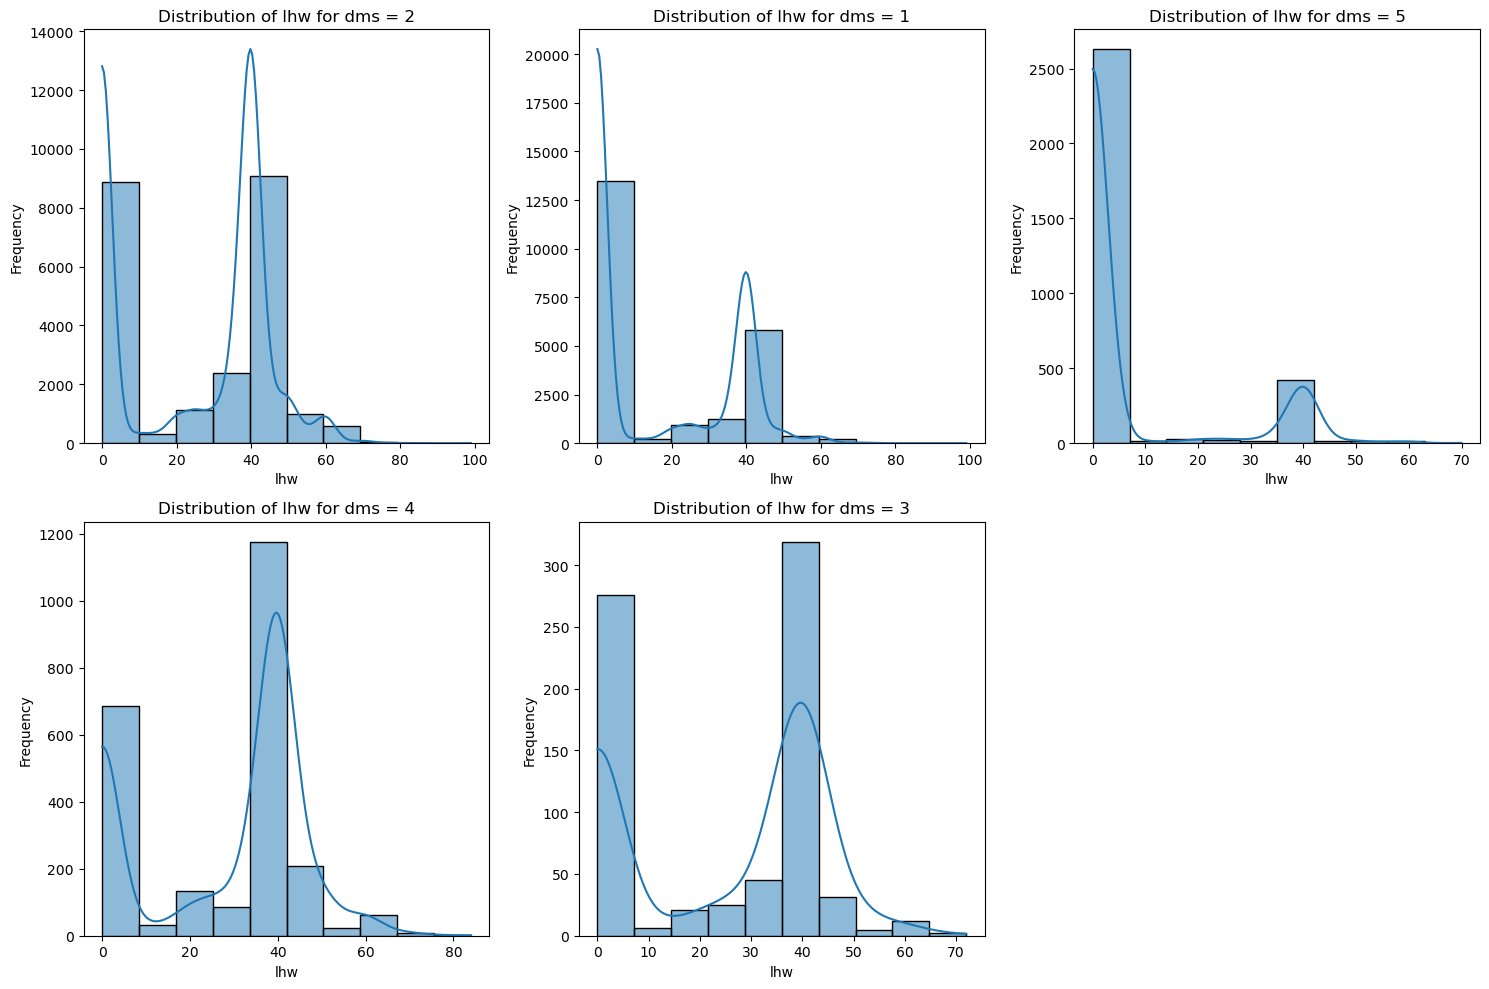

In [13]:
# Get the unique values of 'les'
unique_dms_values = df['dms'].unique()

# Determine the number of unique values
n_unique_dms = len(unique_dms_values)

# Create subplots - adjust the number of rows and columns as needed
n_cols = 3
n_rows = (n_unique_dms + n_cols - 1) // n_cols  # to ensure all subplots fit

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()  # Flatten in case of a single row

# Plot each segment
for i, dms_value in enumerate(unique_dms_values):
    ax = axes[i]
    segment_df = df[df['dms'] == dms_value]
    sns.histplot(segment_df['lhw'], bins=10, kde=True, ax=ax)
    ax.set_title(f'Distribution of lhw for dms = {dms_value}')
    ax.set_xlabel('lhw')
    ax.set_ylabel('Frequency')

# Hide any unused subplots
for i in range(n_unique_dms, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [14]:
# Filter the mixed income data to find singles
singles_with_mixed_income = mixed_income_data1[mixed_income_data1['dms'] != 2]

# Count the number of singles
number_of_singles_with_mixed_income = singles_with_mixed_income.shape[0]

# Output the result
print(f"Number of individuals with mixed income who are single: {number_of_singles_with_mixed_income}")


Number of individuals with mixed income who are single: 340


In [15]:
# Ensure correct classification of les
df.loc[(df['les'] != 2) & (df['les'] != 3) & (df['lhw'] > 5) & (df['yem'] > 400), 'les'] = 3
df.loc[(df['les'] != 2) & (df['les'] != 3) & (df['lhw'] > 5) & (df['yse'] > 400), 'les'] = 2

# For mixed income cases
df.loc[(df['les'] != 2) & (df['les'] != 3) & (df['lhw'] > 5) & (df['yem'] > 400) & (df['yse'] > 400), 'les'] = df.apply(lambda row: 2 if row['yse'] > row['yem'] else 3, axis=1)

# Calculate wage for those with les = 2 and lhw > 5
df.loc[(df['les'] == 2) & (df['lhw'] > 5), 'wage'] = df['yse'] / (df['lhw'] * (52/12))

# Calculate wage for those with les = 3 and lhw > 5
df.loc[(df['les'] == 3) & (df['lhw'] > 5), 'wage'] = df['yem'] / (df['lhw'] * (52/12))

# Display the data to verify
print(df[['idperson', 'les', 'lhw', 'yse', 'yem', 'wage']].head())

   idperson  les  lhw      yse      yem       wage
0  86990001    5    0     0.00     0.00        NaN
1  86990002    2   40  2212.11     0.00  12.762173
2  86990003    6    0     0.00     0.00        NaN
3  87010001    3   42     0.00  2676.51  14.706099
4  87010002    3   40     0.00  4256.44  24.556385


In [16]:
# Filter the dataset for working age individuals
df1 = df[(df['dag'] >= 18) & (df['dag'] <= 65)].copy()

In [17]:
# Create a binary variable indicating if the individual is working (lhw > 5)
df1['working'] = (df1['lhw'] > 5).astype(int)

# Define predictors for the selection model
selection_formula = 'working ~ dag + C(dct) + C(dcz) + C(ddi) + C(dec) + C(deh) + C(dgn) + C(dms) + dncsy + drgmd + drgn1 + drgn2 + drgru + drgur'

# First Stage: Probit model to determine the probability of working
selection_model = smf.probit(selection_formula, data=df1).fit()

# Calculate predicted probabilities
df1['predicted_prob'] = selection_model.predict(df1)

# Calculate the Inverse Mills Ratio
df1['mills_ratio'] = norm.pdf(selection_model.fittedvalues) / norm.cdf(selection_model.fittedvalues)

# Define predictors for the outcome model
outcome_formula = 'wage ~ dag + C(dct) + C(dcz) + C(ddi) + C(dec) + C(deh) + C(dgn) + C(dms) + dncsy + drgmd + drgn1 + drgn2 + drgru + drgur + mills_ratio'


         Current function value: 0.440870
         Iterations: 35


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [18]:
# Second Stage: OLS model to estimate wages for those who are working
working_df = df1[df1['working'] == 1]
outcome_model = smf.ols(outcome_formula, data=working_df).fit()

# Predict wages for those who are not working
non_working_df = df1[df1['working'] == 0]
df1.loc[df1['working'] == 0, 'wage'] = outcome_model.predict(non_working_df)



In [19]:
print(df[['idperson', 'les', 'dag','lhw', 'yse', 'yem', 'wage','yivwg']].head())
print(df1[['idperson', 'les', 'dag','lhw', 'yse', 'yem', 'wage','yivwg']].head())

   idperson  les  dag  lhw      yse      yem       wage  yivwg
0  86990001    5   59    0     0.00     0.00        NaN  47.39
1  86990002    2   59   40  2212.11     0.00  12.762173  19.43
2  86990003    6   22    0     0.00     0.00        NaN  10.15
3  87010001    3   65   42     0.00  2676.51  14.706099  14.71
4  87010002    3   65   40     0.00  4256.44  24.556385  21.00
   idperson  les  dag  lhw      yse      yem       wage  yivwg
0  86990001    5   59    0     0.00     0.00  13.503312  47.39
1  86990002    2   59   40  2212.11     0.00  12.762173  19.43
2  86990003    6   22    0     0.00     0.00   7.716787  10.15
3  87010001    3   65   42     0.00  2676.51  14.706099  14.71
4  87010002    3   65   40     0.00  4256.44  24.556385  21.00


In [20]:
# Identify the Head of the Household
df['is_head'] = df.groupby('idhh')['idperson'].transform(lambda x: x == x.min()).astype(int)

# Step 1: Aggregate Disposable Income of Other Members as Unearned Income for the Head of the Household
def calculate_unearned_income(hh_df):
    hh_df['yds_other'] = hh_df['ils_udb_yds'].sum() - hh_df['ils_udb_yds']
    return hh_df


In [21]:
# Apply the function to calculate yds_other for all households
df = df.groupby('idhh').apply(calculate_unearned_income)
df['yds_other'] = df['yds_other'].fillna(0)

# Step 3: Filter to keep only the heads of households
heads_of_households = df[df['is_head'] == 1]

# Step 4: Further filter the data to include only heads aged 16-65, with LES type 2, 3, or 7, and who are not married
filtered_heads = heads_of_households[
    (heads_of_households['dag'] >= 16) & (heads_of_households['dag'] <= 65) &
    (heads_of_households['les'].isin([2, 3, 7])) &
    (heads_of_households['dms'] != 2)
]

# Remove the temporary 'is_head' column
filtered_heads = filtered_heads.drop(columns=['is_head'])

# Display the DataFrame to verify the results
print(filtered_heads[['idperson', 'idhh', 'dms', 'ils_udb_yds', 'yds_other']].head())

           idperson    idhh  dms  ils_udb_yds  yds_other
idhh                                                    
870600 11  87060001  870600    1      2543.76       0.00
870700 12  87070001  870700    5      1273.29       0.00
870900 13  87090001  870900    1      3312.07       0.00
873800 23  87380001  873800    1      1574.65    1661.29
877000 52  87700002  877000    4      1271.57       0.00


In [22]:
filtered_df = filtered_heads.copy()

In [23]:
# Define the function to classify original scenario based on lhw
def original_scenario(lhw):
    if lhw == 0:
        return 'h0'
    elif 1 <= lhw <= 25:
        return 'h1'
    elif 26 <= lhw <= 48:
        return 'h2'
    elif lhw > 48:
        return 'h3'
    else:
        return 'unknown'

# Apply the original_scenario function to classify scenarios
filtered_df['original_scenario'] = filtered_df['lhw'].apply(original_scenario)

# Create a new column 'working_status' where the value is 1 if 'lhw' > 0, else 0
filtered_df['working_status'] = np.where(filtered_df['lhw'] > 0, 1, 0)

In [24]:
# Scale 'lhw' to [0, 1] for parameter estimation
lhw_scaled = (filtered_df['lhw'] - filtered_df['lhw'].min()) / (filtered_df['lhw'].max() - filtered_df['lhw'].min())
mu = lhw_scaled.mean()
sigma_squared = lhw_scaled.var()

# Estimate alpha and beta
alpha_est = mu * ((mu * (1 - mu) / sigma_squared) - 1)
beta_est = (1 - mu) * ((mu * (1 - mu) / sigma_squared) - 1)

print(alpha_est)
print(beta_est)
print(mu)
print(sigma_squared)

8.29716755791654
13.155354244939275
0.3867688672765735
0.010563566652544225


In [25]:
# Define function to generate counterfactual working hours
def generate_counterfactual_lhw(df, alpha, beta):
    np.random.seed(50)  # For reproducibility
    bounds = {'h0': (0, 0), 'h1': (1, 25), 'h2': (26, 48), 'h3': (49, 70)}
    
    # Iterate over each row in DataFrame
    for index, row in df.iterrows():
        # Set lhw value for the original scenario directly from df['lhw']
        df.at[index, f'lhw_{row["original_scenario"]}'] = row['lhw']
        
        # Determine which scenarios to generate counterfactuals for
        scenarios_to_generate = [scenario for scenario in bounds.keys() if scenario != row['original_scenario']]
        
        for scenario in scenarios_to_generate:
            lower_bound, upper_bound = bounds[scenario]
            # Generate and assign counterfactual lhw values for scenarios other than the original
            df.at[index, f'lhw_{scenario}'] = np.ceil(lower_bound + np.random.beta(alpha, beta) * (upper_bound - lower_bound)).astype(int)

# Apply the function to generate counterfactuals
generate_counterfactual_lhw(filtered_df, alpha_est, beta_est)
print(filtered_df[['idperson', 'original_scenario', 'lhw_h0', 'lhw_h1', 'lhw_h2', 'lhw_h3', 'lhw']].head())


           idperson original_scenario  lhw_h0  lhw_h1  lhw_h2  lhw_h3  lhw
idhh                                                                      
870600 11  87060001                h2     0.0    14.0    44.0    57.0   44
870700 12  87070001                h0     0.0    10.0    31.0    57.0    0
870900 13  87090001                h2     0.0    11.0    37.0    56.0   37
873800 23  87380001                h2     0.0     8.0    35.0    56.0   35
877000 52  87700002                h2     0.0     9.0    30.0    56.0   30


In [26]:
# Function to update yem or yse and create scenario-specific datasets give YIVWG
def update_yem_or_yse_create_dataset_and_export(filtered_df, scenario_prefix, filename):
    # Clone the DataFrame
    scenario_df = filtered_df.copy()
    
    # Correctly reference the scenario-specific 'lhw' column
    lhw_column = f'lhw_{scenario_prefix}'  # Adjust to use the correct column name format
    scenario_df['lhw'] = scenario_df[lhw_column]
    
    # Calculate new 'yem' or 'yse' based on the scenario-specific 'lhw'
    scenario_df.loc[scenario_df['les'] == 3, 'yem'] = scenario_df[lhw_column] * (52 / 12) * scenario_df['yivwg']
    scenario_df.loc[scenario_df['les'] == 2, 'yse'] = scenario_df[lhw_column] * (52 / 12) * scenario_df['yivwg']
    
    # Set yem and yse to 0 for scenario h0
    scenario_df.loc[scenario_df['lhw'] == 0, ['yem', 'yse']] = 0
    
    # Export the DataFrame as a text file
    scenario_df.to_csv(f'{filename}.txt', index=False, sep='\t')
    
    # Return the scenario DataFrame for further use
    return scenario_df


In [27]:
# Example usage
scenario_datasets = {}
for scenario_prefix in ['h0', 'h1', 'h2', 'h3']:
    dataset_name = f'scenario_{scenario_prefix}'
    scenario_datasets[scenario_prefix] = update_yem_or_yse_create_dataset_and_export(filtered_df, scenario_prefix, dataset_name)

# Display descriptive statistics for each scenario
for scenario, df_scenario in scenario_datasets.items():
    print(f"Descriptive Statistics for {scenario}:")
    display(df_scenario[['lhw', 'yem', 'yse', 'yds','ils_udb_yds','yds_other','yivwg', 'lhw_h0', 'lhw_h1', 'lhw_h2', 'lhw_h3']].describe())
    print("\n")


Descriptive Statistics for h0:


,lhw,yem,yse,yds,ils_udb_yds,yds_other,yivwg,lhw_h0,lhw_h1,lhw_h2,lhw_h3
count,5515.0,5515.0,5515.0,5515.000000,5515.000000,5515.000000,5515.000000,5515.0,5515.000000,5515.000000,5515.000000
mean,0.0,0.0,0.0,2360.117039,1662.653552,741.218847,13.865655,0.0,11.625929,38.158114,57.400544
std,0.0,0.0,0.0,1531.613668,1054.045806,1096.743182,9.236783,0.0,3.824432,3.624317,2.967793
min,0.0,0.0,0.0,-2694.250000,-597.730000,-723.160000,0.010000,0.0,1.000000,26.000000,49.000000
25%,0.0,0.0,0.0,1311.840000,994.720000,0.000000,8.130000,0.0,9.000000,35.000000,56.000000
50%,0.0,0.0,0.0,2075.150000,1453.010000,0.000000,12.030000,0.0,11.000000,40.000000,57.000000
75%,0.0,0.0,0.0,3032.360000,2138.045000,1296.800000,17.720000,0.0,13.000000,40.000000,59.000000
max,0.0,0.0,0.0,17089.260000,16478.330000,12898.360000,149.510000,0.0,25.000000,48.000000,99.000000




Descriptive Statistics for h1:


,lhw,yem,yse,yds,ils_udb_yds,yds_other,yivwg,lhw_h0,lhw_h1,lhw_h2,lhw_h3
count,5515.000000,5515.000000,5515.000000,5515.000000,5515.000000,5515.000000,5515.000000,5515.0,5515.000000,5515.000000,5515.000000
mean,11.625929,620.090051,87.063452,2360.117039,1662.653552,741.218847,13.865655,0.0,11.625929,38.158114,57.400544
std,3.824432,586.126421,313.155637,1531.613668,1054.045806,1096.743182,9.236783,0.0,3.824432,3.624317,2.967793
min,1.000000,0.000000,0.000000,-2694.250000,-597.730000,-723.160000,0.010000,0.0,1.000000,26.000000,49.000000
25%,9.000000,278.113333,0.000000,1311.840000,994.720000,0.000000,8.130000,0.0,9.000000,35.000000,56.000000
50%,11.000000,504.746667,0.000000,2075.150000,1453.010000,0.000000,12.030000,0.0,11.000000,40.000000,57.000000
75%,13.000000,837.200000,0.000000,3032.360000,2138.045000,1296.800000,17.720000,0.0,13.000000,40.000000,59.000000
max,25.000000,14578.010000,11500.440000,17089.260000,16478.330000,12898.360000,149.510000,0.0,25.000000,48.000000,99.000000




Descriptive Statistics for h2:


,lhw,yem,yse,yds,ils_udb_yds,yds_other,yivwg,lhw_h0,lhw_h1,lhw_h2,lhw_h3
count,5515.000000,5515.000000,5515.000000,5515.000000,5515.000000,5515.000000,5515.000000,5515.0,5515.000000,5515.000000,5515.000000
mean,38.158114,2025.948717,253.458070,2360.117039,1662.653552,741.218847,13.865655,0.0,11.625929,38.158114,57.400544
std,3.624317,1668.086845,768.188791,1531.613668,1054.045806,1096.743182,9.236783,0.0,3.824432,3.624317,2.967793
min,26.000000,0.000000,0.000000,-2694.250000,-597.730000,-723.160000,0.010000,0.0,1.000000,26.000000,49.000000
25%,35.000000,975.953333,0.000000,1311.840000,994.720000,0.000000,8.130000,0.0,9.000000,35.000000,56.000000
50%,40.000000,1750.666667,0.000000,2075.150000,1453.010000,0.000000,12.030000,0.0,11.000000,40.000000,57.000000
75%,40.000000,2764.666667,0.000000,3032.360000,2138.045000,1296.800000,17.720000,0.0,13.000000,40.000000,59.000000
max,48.000000,22027.806667,11500.440000,17089.260000,16478.330000,12898.360000,149.510000,0.0,25.000000,48.000000,99.000000




Descriptive Statistics for h3:


,lhw,yem,yse,yds,ils_udb_yds,yds_other,yivwg,lhw_h0,lhw_h1,lhw_h2,lhw_h3
count,5515.000000,5515.000000,5515.000000,5515.000000,5515.000000,5515.000000,5515.000000,5515.0,5515.000000,5515.000000,5515.000000
mean,57.400544,3033.555082,381.698893,2360.117039,1662.653552,741.218847,13.865655,0.0,11.625929,38.158114,57.400544
std,2.967793,2506.985895,1149.775186,1531.613668,1054.045806,1096.743182,9.236783,0.0,3.824432,3.624317,2.967793
min,49.000000,0.000000,0.000000,-2694.250000,-597.730000,-723.160000,0.010000,0.0,1.000000,26.000000,49.000000
25%,56.000000,1478.001667,0.000000,1311.840000,994.720000,0.000000,8.130000,0.0,9.000000,35.000000,56.000000
50%,57.000000,2605.850000,0.000000,2075.150000,1453.010000,0.000000,12.030000,0.0,11.000000,40.000000,57.000000
75%,59.000000,4147.130000,0.000000,3032.360000,2138.045000,1296.800000,17.720000,0.0,13.000000,40.000000,59.000000
max,99.000000,36928.970000,11500.440000,17089.260000,16478.330000,12898.360000,149.510000,0.0,25.000000,48.000000,99.000000


In [29]:
filtered_df.to_csv('1hhdmodel.csv', index=False)